## Model hypeparametrization
Using Optuna and RandomSearch to finetune model parameters to improve prediction performance

In [41]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from lightgbm import LGBMClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import shap
import joblib
import json
from datetime import date

from warnings import filterwarnings
filterwarnings('ignore')
from sklearn import set_config
set_config(display="text")


In [42]:
DATA_DIR = "../data"
RESULTS_DIR = "../results"

os.makedirs(f"{RESULTS_DIR}/model/optimization/", exist_ok=True)

### Load data

In [43]:
### Load merged df
df = pd.read_csv(f"{DATA_DIR}/preprocessed_df.csv")
df.head()

,record_id,sexo,fecha_ingreso,fecha_alta,foco_controlable,IRAs_nosocomial,mortalidad,fecha_mortalidad,dias_hemocultivo_mortalidad,mortalidad_30_dias,...,cateter_venoso,sonda_urinaria,sonda_nasogastrica,derivacion_ventriculoper,valvula_prot_cardiaca,portador_otros_disposit,antimicrobiano_list,cmi_list,interpretacion_list,antimicrobiano_family_list
0,1,0,2021-08-24,2021-09-09,NaN,1,1,2021-09-09,9.0,1,...,0,0,1,0,0,0,"['Cefazolina', 'Trimetoprim', 'Ertapenem', 'Ce...","['>16 mg/L', '>4 mg/L', '>1 mg/L', '>8 mg/L', ...","['R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'I', ...","['Cefalosporin', 'TMP_SMX', 'Carbapenem', 'Cef..."
1,2,1,2023-06-18,2023-07-13,NaN,1,0,NaN,NaN,0,...,0,0,1,0,0,0,"['Trimetroprim/sulfametoxazol', 'Cefuroxima', ...","['>4/76 mg/L', '<=8 mg/L', '0.5 mg/L', '<=0.5 ...","['R', 'I', 'I', 'S', 'S', 'S', 'S', 'S', 'S', ...","['TMP_SMX', 'Cefalosporin', 'Quinolone', 'Quin..."
2,3,0,2022-02-11,2022-04-06,1.0,1,0,NaN,NaN,0,...,0,0,1,0,0,0,"['Trimetroprim/sulfametoxazol', 'Ampicilina', ...","['>4/76 mg/L', '>8 mg/L', '>4 mg/L', '>1 mg/L'...","['R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', ...","['TMP_SMX', 'Penicillin', 'Aminoglycoside', 'Q..."
3,4,0,2021-05-15,2021-07-28,NaN,1,0,NaN,NaN,0,...,0,0,1,0,0,0,"['Trimetoprim', 'Levofloxacino', 'Ertapenem', ...","['>4 mg/L', '>1 mg/L', '>1 mg/L', '>16 mg/L', ...","['R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', ...","['TMP_SMX', 'Quinolone', 'Carbapenem', 'Cefalo..."
4,5,1,2021-07-04,2022-01-04,0.0,1,0,NaN,NaN,0,...,0,0,0,0,0,0,"['Aztreonam', 'Ciprofloxacino', 'Ceftazidima',...","['<=1 mg/L', '>1 mg/L', '<=1 mg/L', '>8 mg/L',...","['R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', ...","['Monobactam', 'Quinolone', 'Cefalosporin', 'C..."


### Mortality imbalance

In [44]:
print(f"Mortality at 30 days: {df['mortalidad_30_dias'].sum()/df.shape[0]*100:.2f}% of total records")  # target prevalence

Mortality at 30 days: 18.36% of total records


### Target and non-target columns

In [45]:
TARGET = "mortalidad_30_dias"

NONTARGETCOLS = ["record_id", "episode_id", "fecha_ingreso", "fecha_alta", "fecha_mortalidad", "mortalidad","dias_hemocultivo_mortalidad",
             "microorganismos_dict", "fechas_dict", "especimen_dict", "duracion_UCI","uci_por_el_episodio", "antimicrobiano_list", "cmi_list",
             "interpretacion_list", "antimicrobiano_family_list"]

df_ = df.drop(columns=NONTARGETCOLS) 

### Missing values heatmap

In [46]:
NA_THRESHOLD = 5

In [47]:
na_tbl = df_.isna().sum().sort_values(ascending=False)
missing_vars = []

for col in na_tbl[na_tbl > 0].index:
    pct = na_tbl[col] / len(df_) * 100
    if pct > NA_THRESHOLD:
        missing_vars.append(col)
        print(f"{col}: {na_tbl[col]} missing values --> {pct:.2f}% NaN")

taquipnea: 3845 missing values --> 97.24% NaN
frecuencia_respiratoria: 3845 missing values --> 97.24% NaN
hipotermia_hipertermia: 3592 missing values --> 90.84% NaN
taquicardia: 3384 missing values --> 85.58% NaN
hipoxemia: 3381 missing values --> 85.51% NaN
barthel_inf_90: 3042 missing values --> 76.93% NaN
foco_controlable: 2365 missing values --> 59.81% NaN
disuria: 1489 missing values --> 37.66% NaN
dolor_abdominal: 1479 missing values --> 37.41% NaN
vomitos: 1479 missing values --> 37.41% NaN
fiebre: 1479 missing values --> 37.41% NaN
tos: 1479 missing values --> 37.41% NaN
dificultad_respirar: 1479 missing values --> 37.41% NaN
lesiones_piel: 1479 missing values --> 37.41% NaN
diarrea: 1479 missing values --> 37.41% NaN
tenesmo_ano_recto: 1479 missing values --> 37.41% NaN
dolor_fosa_renal: 1479 missing values --> 37.41% NaN
nauseas: 1479 missing values --> 37.41% NaN
tenesmo_vejiga: 1479 missing values --> 37.41% NaN
cefalea: 1479 missing values --> 37.41% NaN
dolores_articulare

In [48]:
# drop variables with too many missing values
df_ = df_.drop(columns=missing_vars)
print(f"Dropped {len(missing_vars)} variables with more than {NA_THRESHOLD}% missing values.")

Dropped 25 variables with more than 5% missing values.


In [49]:
# df dimensionality after dropping columns
print(f"Dataframe shape after dropping columns: {df_.shape}")

Dataframe shape after dropping columns: (3954, 106)


## Data Preprocessing

In [50]:
# Prepare data
X = df_.drop(columns=[TARGET])
y = df_[TARGET]

### Split data into train and tests sets
- Train / Validation: **70%** (80% train, 20% validation)
- Test: **30%**

In [51]:
# Split train (train+validation) and test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)


## Model Finetuning

Selected models for finetuning (based on performance):
- Random Forest
- XGBoost
- LightGBM

### Target imbalance

In [52]:
# mortality at 30 days imbalance 
print(f"Mortality at 30 days: {(y==1).sum()/len(y)*100:.2f}%")
prevalence = (y==1).sum()/len(y)

imbalance_ratio = (y==0).sum()/(y==1).sum()
print(f"Imbalance ratio: {imbalance_ratio}")

Mortality at 30 days: 18.36%
Imbalance ratio: 4.446280991735537


## Random Forest

In [53]:
# Option A: single validation split (fast)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=42
)


In [54]:
# hyperparameter tuning 
param_dist_rf = {
    "n_estimators": [500, 800, 1200],
    "max_depth": [None, 4, 6, 8],
    "min_samples_leaf": [5, 10, 20, 40],
    "min_samples_split": [10, 20, 50],
    "max_features": ["sqrt", 0.3, 0.5],
}

rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

search_rf = RandomizedSearchCV(
    rf,
    param_distributions=param_dist_rf,
    n_iter=50,          
    scoring="average_precision",
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search_rf.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    n_jobs=-1,
                                                    random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'max_depth': [None, 4, 6, 8],
                                        'max_features': ['sqrt', 0.3, 0.5],
                                        'min_samples_leaf': [5, 10, 20, 40],
                                        'min_samples_split': [10, 20, 50],
                                        'n_estimators': [500, 800, 1200]},
                   random_state=42, scoring='average_precision', verbose=1)

In [55]:
# Best hyperparameters
best_rf = search_rf.best_estimator_

print("Best CV PR-AUC:", search_rf.best_score_)
print("Best parameters:", search_rf.best_params_)
print("-------------")
results = pd.DataFrame(search_rf.cv_results_)
print(results.sort_values("mean_test_score", ascending=False).head(5)[['mean_test_score', 'std_test_score']])

Best CV PR-AUC: 0.4689774480395011
Best parameters: {'n_estimators': 800, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 0.5, 'max_depth': None}
-------------
    mean_test_score  std_test_score
43         0.468977        0.054015
17         0.467021        0.052596
35         0.458300        0.055113
1          0.458016        0.053439
47         0.456827        0.057399


In [56]:
# fit best model hyperparameters
best_rf.fit(X_train, y_train)

# calibrate probabilities
calibrated_rf = CalibratedClassifierCV(best_rf, method='isotonic', cv=5)
calibrated_rf.fit(X_train, y_train)

y_prob = calibrated_rf.predict_proba(X_test)[:,1]

precision, recall, _ = precision_recall_curve(y_test, y_prob)

roc_test = roc_auc_score(y_test, y_prob)
pr_test = average_precision_score(y_test, y_prob)    

print("Best CV PR-AUC:", search_rf.best_score_)
print("Best parameters:", search_rf.best_params_)
print("---------------")
print(f"RF test ROC-AUC: {roc_test:.3f}")
print(f"RF test PR-AUC: {pr_test:.3f}")


Best CV PR-AUC: 0.4689774480395011
Best parameters: {'n_estimators': 800, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 0.5, 'max_depth': None}
---------------
RF test ROC-AUC: 0.731
RF test PR-AUC: 0.438


### Plot

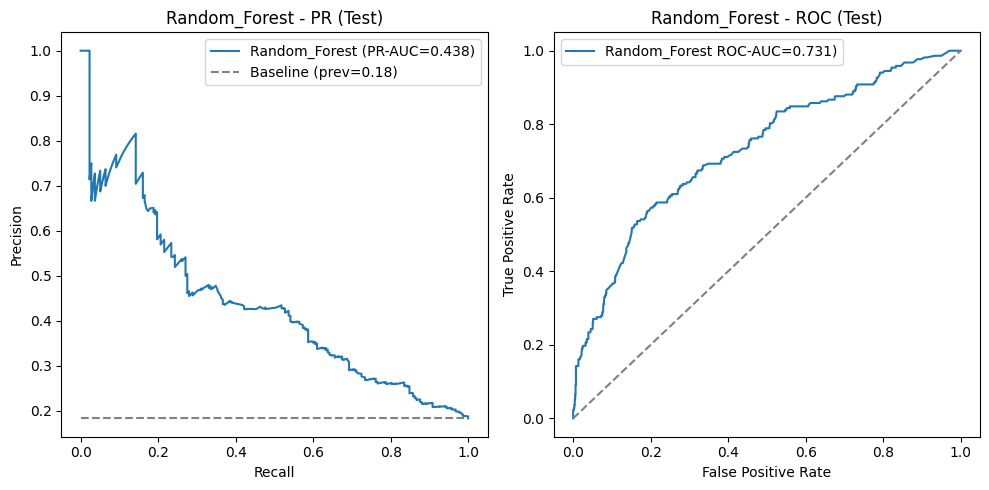

In [57]:
fig, ax = plt.subplots(1,2,figsize=(10,5))

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)

ax[0].plot(
    recall,
    precision,
    label=f"Random_Forest (PR-AUC={pr_test:.3f})"
)

baseline = y_test.mean()
ax[0].hlines(
    baseline, 0, 1,
    linestyles="dashed", colors="grey",
    label=f"Baseline (prev={baseline:.2f})"
)

ax[0].set_xlabel("Recall")
ax[0].set_ylabel("Precision")
ax[0].set_title("Random_Forest - PR (Test)")
ax[0].legend()

# --------------------
# ROC
# --------------------

fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)

ax[1].plot(
    fpr,
    tpr,
    label=f"Random_Forest ROC-AUC={roc_test:.3f})"
)

ax[1].plot([0, 1], [0, 1], '--', color='grey')
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")
ax[1].set_title("Random_Forest - ROC (Test)")
ax[1].legend()

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/model/optimization/random_forest_pr_roc_curves.png")
plt.show()


## LightGBM

In [58]:
# Option A: single validation split (fast)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=42
)


In [59]:
best_roc = 0
best_pr = 0

def objective(trial):
    global best_roc, best_pr
    params = {
        "objective": "binary",
        "metric": "auc",  # used for pruning
        "class_pos_weight": imbalance_ratio,
        "boosting_type": "gbdt",
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 16, 256),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 200),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "lambda_l1": trial.suggest_float("lambda_l1", 1e-8, 10.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 1e-8, 10.0, log=True),
        "verbosity": -1,
        "seed": 42,
    }

    # Training
    
    dtrain = lgb.Dataset(X_train, label=y_train)
    dvalid = lgb.Dataset(X_val, label=y_val)

    pruning_callback = optuna.integration.LightGBMPruningCallback(
        trial, metric="auc"
    )
    model = lgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        valid_sets=[dvalid],
        callbacks=[
            pruning_callback,
            lgb.early_stopping(50, verbose=False),
        ]
    )

    y_pred_cv = model.predict(X_val, num_iteration=model.best_iteration)

    roc = roc_auc_score(y_val, y_pred_cv)
    pr  = average_precision_score(y_val, y_pred_cv)

    # Store metrics
    trial.set_user_attr("roc_auc", roc)
    trial.set_user_attr("pr_auc", pr)

    # Only print if new PR-AUC is higher than previous best
    if pr > best_pr:
        best_roc = roc
        best_pr  = pr
        print(f"New best trial {trial.number}: ROC={roc:.4f}, PR={pr:.4f}")

    return roc


In [60]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

study_lgb = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)
)

study_lgb.optimize(objective, n_trials=100)


New best trial 0: ROC=0.7189, PR=0.3793
New best trial 1: ROC=0.7365, PR=0.4163
New best trial 6: ROC=0.7398, PR=0.4195
New best trial 16: ROC=0.7478, PR=0.4208
New best trial 25: ROC=0.7595, PR=0.4247
New best trial 41: ROC=0.7637, PR=0.4276
New best trial 62: ROC=0.7601, PR=0.4323
New best trial 78: ROC=0.7633, PR=0.4344


In [61]:
# fit best hyperparameter conf
best_params = study_lgb.best_trial.params
best_params.update({
    "objective": "binary",
    "metric": "auc",
    "verbosity": -1,
})

final_lgb = lgb.LGBMClassifier(
    **best_params,
    n_estimators=1000
)

final_lgb.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(50, verbose=False)],
)


LGBMClassifier(colsample_bytree=0.512768106608374,
               lambda_l1=2.6232024605708887e-08, lambda_l2=0.13192137187233144,
               learning_rate=0.018026916126219622, max_depth=8, metric='auc',
               min_child_samples=5, n_estimators=1000, num_leaves=39,
               objective='binary', subsample=0.9939038625101154, verbosity=-1)

### Predict optimized model on test set

In [62]:
y_pred = final_lgb.predict_proba(X_test)[:, 1]

roc_test = roc_auc_score(y_test, y_pred)
pr_test  = average_precision_score(y_test, y_pred)

summary = f"""
LIGHTGBM
Best trial (validation):
  ROC-AUC: {study_lgb.best_trial.user_attrs['roc_auc']:.4f}
  PR-AUC:  {study_lgb.best_trial.user_attrs['pr_auc']:.4f}

Test set:
  ROC-AUC: {roc_test:.4f}
  PR-AUC:  {pr_test:.4f}
"""

print(summary)



LIGHTGBM
Best trial (validation):
  ROC-AUC: 0.7724
  PR-AUC:  0.4183

Test set:
  ROC-AUC: 0.7399
  PR-AUC:  0.4422



### Plot

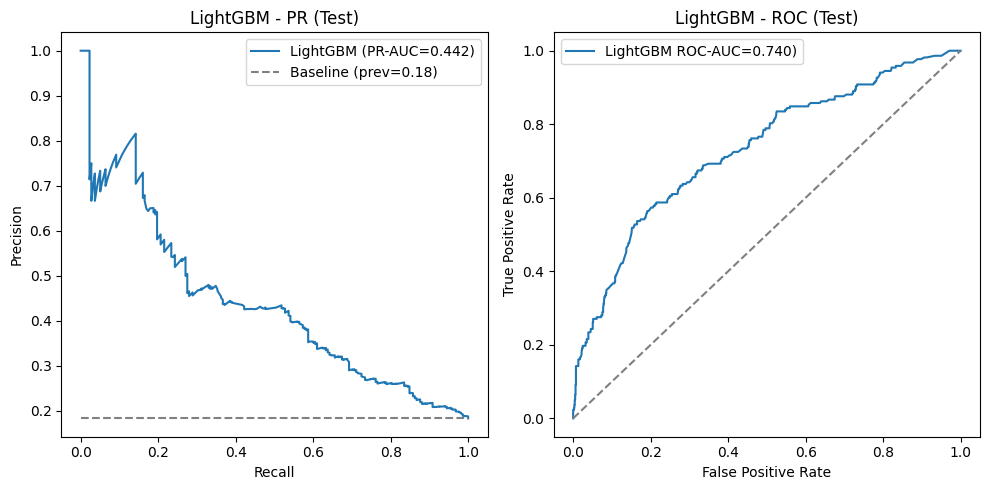

In [63]:
fig, ax = plt.subplots(1,2,figsize=(10,5))

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)

ax[0].plot(
    recall,
    precision,
    label=f"LightGBM (PR-AUC={pr_test:.3f})"
)

baseline = y_test.mean()
ax[0].hlines(
    baseline, 0, 1,
    linestyles="dashed", colors="grey",
    label=f"Baseline (prev={baseline:.2f})"
)

ax[0].set_xlabel("Recall")
ax[0].set_ylabel("Precision")
ax[0].set_title("LightGBM - PR (Test)")
ax[0].legend()

# --------------------
# ROC
# --------------------

fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)

ax[1].plot(
    fpr,
    tpr,
    label=f"LightGBM ROC-AUC={roc_test:.3f})"
)

ax[1].plot([0, 1], [0, 1], '--', color='grey')
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")
ax[1].set_title("LightGBM - ROC (Test)")
ax[1].legend()

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/model/optimization/lightgbm_pr_roc_curves.png")
plt.show()


## XGBoost - optuna

In [64]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=42
)

In [65]:
best_pr = 0
best_roc = 0

def objective(trial):
    global best_pr, best_roc
    # Suggest hyperparameters
    params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",  # used for pruning
        "class_pos_weight": imbalance_ratio,
        "tree_method": "hist",  # fast
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "min_child_weight": trial.suggest_float("min_child_weight", 1e-3, 10.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state": 42,
    }


    # Training
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dvalid = xgb.DMatrix(X_val, label=y_val)

    pruning_callback = optuna.integration.XGBoostPruningCallback(
        trial, "validation_0-auc"
    )

    evals_result = {}
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        evals=[(dvalid, "validation_0")],
        early_stopping_rounds=50,
        verbose_eval=False,
        callbacks=[pruning_callback],
        evals_result=evals_result
    )

    # Predictions
    y_pred_cv = model.predict(dvalid, iteration_range=(0, model.best_iteration))

    # Metrics
    roc = roc_auc_score(y_val, y_pred_cv)
    pr = average_precision_score(y_val, y_pred_cv)

    # Store metrics
    trial.set_user_attr("roc_auc", roc)
    trial.set_user_attr("pr_auc", pr)

    # Only print if new PR-AUC is higher than previous best
    if pr > best_pr:
        best_roc = roc
        best_pr  = pr
        print(f"New best trial {trial.number}: ROC={roc:.4f}, PR={pr:.4f}")

    # Return ROC-AUC for Optuna to maximize (pruning callback watches this)
    return roc


### Run optimization

In [66]:
# run optuna
study_xgb = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner(n_warmup_steps=10))
study_xgb.optimize(objective, n_trials=100)

New best trial 0: ROC=0.7597, PR=0.3979
New best trial 1: ROC=0.7504, PR=0.4040
New best trial 2: ROC=0.7479, PR=0.4341
New best trial 53: ROC=0.7602, PR=0.4507


In [67]:
# fit best hypermparametrization

best_params = study_xgb.best_trial.params
best_params.update({"objective": "binary:logistic", "eval_metric": "auc", "tree_method": "hist"})

final_xgb = xgb.XGBClassifier(
    **best_params,
    n_estimators=1000  # let early stopping during .fit() handle iterations
)
final_xgb.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6427980379595764, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='auc', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1415480966029565,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=0.004951007178664177, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, ...)

### Predict optimized model on test set

In [68]:
y_pred = final_xgb.predict_proba(X_test)[:, 1]

roc_test = roc_auc_score(y_test, y_pred)
pr_test  = average_precision_score(y_test, y_pred)

summary = f"""
XGBOOST
Best trial (validation):
  ROC-AUC: {study_xgb.best_trial.user_attrs['roc_auc']:.4f}
  PR-AUC:  {study_xgb.best_trial.user_attrs['pr_auc']:.4f}

Test set:
  ROC-AUC: {roc_test:.4f}
  PR-AUC:  {pr_test:.4f}
"""

print(summary)



XGBOOST
Best trial (validation):
  ROC-AUC: 0.7615
  PR-AUC:  0.4022

Test set:
  ROC-AUC: 0.7045
  PR-AUC:  0.4037



### Plot

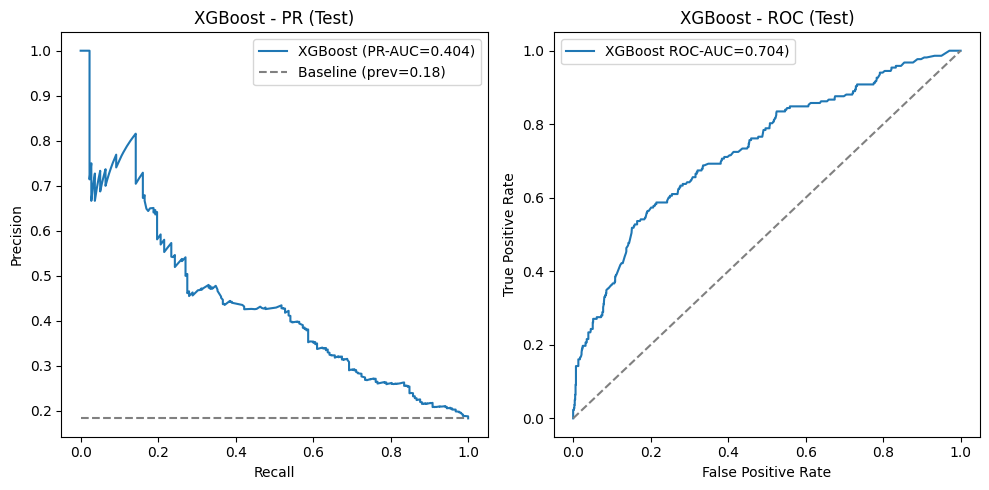

In [69]:
fig, ax = plt.subplots(1,2,figsize=(10,5))

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)

ax[0].plot(
    recall,
    precision,
    label=f"XGBoost (PR-AUC={pr_test:.3f})"
)

baseline = y_test.mean()
ax[0].hlines(
    baseline, 0, 1,
    linestyles="dashed", colors="grey",
    label=f"Baseline (prev={baseline:.2f})"
)

ax[0].set_xlabel("Recall")
ax[0].set_ylabel("Precision")
ax[0].set_title("XGBoost - PR (Test)")
ax[0].legend()

# --------------------
# ROC
# --------------------

fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)

ax[1].plot(
    fpr,
    tpr,
    label=f"XGBoost ROC-AUC={roc_test:.3f})"
)

ax[1].plot([0, 1], [0, 1], '--', color='grey')
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")
ax[1].set_title("XGBoost - ROC (Test)")
ax[1].legend()

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/model/optimization/xgboost_pr_roc_curves.png")
plt.show()


## CatBoost

In [86]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=42
)

In [91]:
best_pr = 0
best_roc = 0

def objective(trial):
    global best_pr, best_roc
    
    params_ctb = {
        "iterations": 3000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "depth": trial.suggest_int("depth", 4, 6),  # 🔴 constrain depth
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 5.0, 80.0, log=True),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 50, 300),
        "random_strength": trial.suggest_float("random_strength", 0.0, 1.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.3, 2.0),
        "bootstrap_type": "Bayesian",
        "loss_function": "Logloss",
        "eval_metric": "PRAUC",
        "class_weights": [
            1.0,
            trial.suggest_float("pos_weight", imbalance_ratio * 0.5, imbalance_ratio * 1.5)
        ],
        "random_seed": 42,
        "verbose": False,
        "allow_writing_files": False,
    }

    model = CatBoostClassifier(**params_ctb)

    model.fit(
        X_train,
        y_train,
        eval_set=(X_val, y_val),
        early_stopping_rounds=100,
        use_best_model=True,
        verbose=False
    )

    y_pred = model.predict_proba(X_val)[:, 1]

    pr_auc  = average_precision_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_pred)

    # Store both metrics
    trial.set_user_attr("roc_auc", roc_auc)
    trial.set_user_attr("pr_auc", pr_auc)

    # Only print if new PR-AUC is higher than previous best
    if pr_auc > best_pr:
        best_roc = roc_auc
        best_pr  = pr_auc
        print(f"New best trial {trial.number}: ROC={roc_auc:.4f}, PR={pr_auc:.4f}")
    return pr_auc  # 🔴 OPTIMIZE WHAT YOU CARE ABOUT


In [92]:
# run optuna
study_ctb= optuna.create_study(direction="maximize", pruner=None)
# study_xgb = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner(n_warmup_steps=10))
study_ctb.optimize(objective, n_trials=100)

New best trial 0: ROC=0.7577, PR=0.4231
New best trial 2: ROC=0.7656, PR=0.4243
New best trial 3: ROC=0.7615, PR=0.4299
New best trial 4: ROC=0.7617, PR=0.4657
New best trial 31: ROC=0.7600, PR=0.4690
New best trial 42: ROC=0.7679, PR=0.4707
New best trial 59: ROC=0.7665, PR=0.4743
New best trial 98: ROC=0.7663, PR=0.4811


In [93]:
# fit best hypermparametrization
best_params_ctb = study_ctb.best_trial.params

# Map tuned parameters to CatBoost
catboost_params = {
    "learning_rate": best_params_ctb["learning_rate"],
    "depth": best_params_ctb["depth"],
    "l2_leaf_reg": best_params_ctb["l2_leaf_reg"],
    "bagging_temperature": best_params_ctb["bagging_temperature"],
    "random_strength": best_params_ctb["random_strength"],
    "loss_function": "Logloss",
    "eval_metric": "PRAUC",
    "class_weights": [1, imbalance_ratio],
    "random_seed": 42,
    "verbose": False,
    "allow_writing_files":False,
    "iterations": 1000,  # max iterations, early stopping will stop sooner
}

final_ctb = CatBoostClassifier(**catboost_params)

final_ctb.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

In [94]:
# save final_ctb for testing
joblib.dump(final_ctb, "../../model/catboost_model.pkl")
joblib.dump(X.columns.values, "../../model/features.pkl")

['../../model/features.pkl']

In [95]:
# save metadata
today = date.today().strftime("%Y-%m-%d")

metadata = {
    "model": "Mortality predictor",
    "version": "1.0",
    "date": today,
    "auc": best_roc,
    "prevalence": prevalence
}

with open("../../model/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)


### Predict optimized model on test set

In [96]:
# predict test set
y_pred = final_ctb.predict_proba(X_test)[:, 1]

roc_test = roc_auc_score(y_test, y_pred)
pr_test  = average_precision_score(y_test, y_pred)

summary = f"""
CATBOOST
Best trial (validation):
  ROC-AUC: {study_ctb.best_trial.user_attrs['roc_auc']:.4f}
  PR-AUC:  {study_ctb.best_trial.user_attrs['pr_auc']:.4f}

Test set:
  ROC-AUC: {roc_test:.4f}
  PR-AUC:  {pr_test:.4f}
"""

print(summary)



CATBOOST
Best trial (validation):
  ROC-AUC: 0.7663
  PR-AUC:  0.4811

Test set:
  ROC-AUC: 0.7150
  PR-AUC:  0.4233



### Plot curves

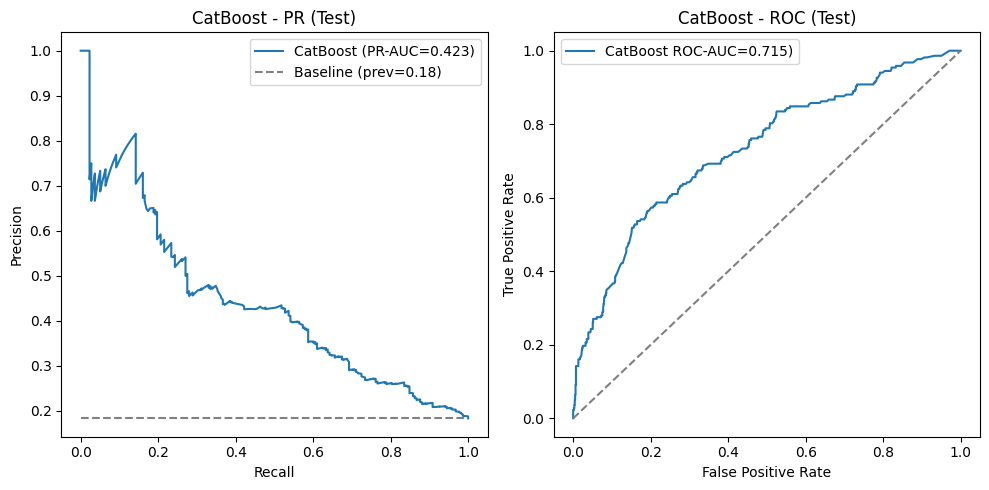

In [97]:
fig, ax = plt.subplots(1,2,figsize=(10,5))

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)

ax[0].plot(
    recall,
    precision,
    label=f"CatBoost (PR-AUC={pr_test:.3f})"
)

ax[0].hlines(
    baseline, 0, 1,
    linestyles="dashed", colors="grey",
    label=f"Baseline (prev={prevalence:.2f})"
)

ax[0].set_xlabel("Recall")
ax[0].set_ylabel("Precision")
ax[0].set_title("CatBoost - PR (Test)")
ax[0].legend()

# --------------------
# ROC
# --------------------

fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)

ax[1].plot(
    fpr,
    tpr,
    label=f"CatBoost ROC-AUC={roc_test:.3f})"
)

ax[1].plot([0, 1], [0, 1], '--', color='grey')
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")
ax[1].set_title("CatBoost - ROC (Test)")
ax[1].legend()

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/model/optimization/catboost_pr_roc_curves.png")
plt.show()
